In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
iris = load_iris()

X = iris.data
y = iris.target


feature_names = iris.feature_names
target_names = iris.target_names

print(feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [3]:
model = DecisionTreeClassifier(
    random_state=42
)
model.fit(X,y)

DecisionTreeClassifier(random_state=42)

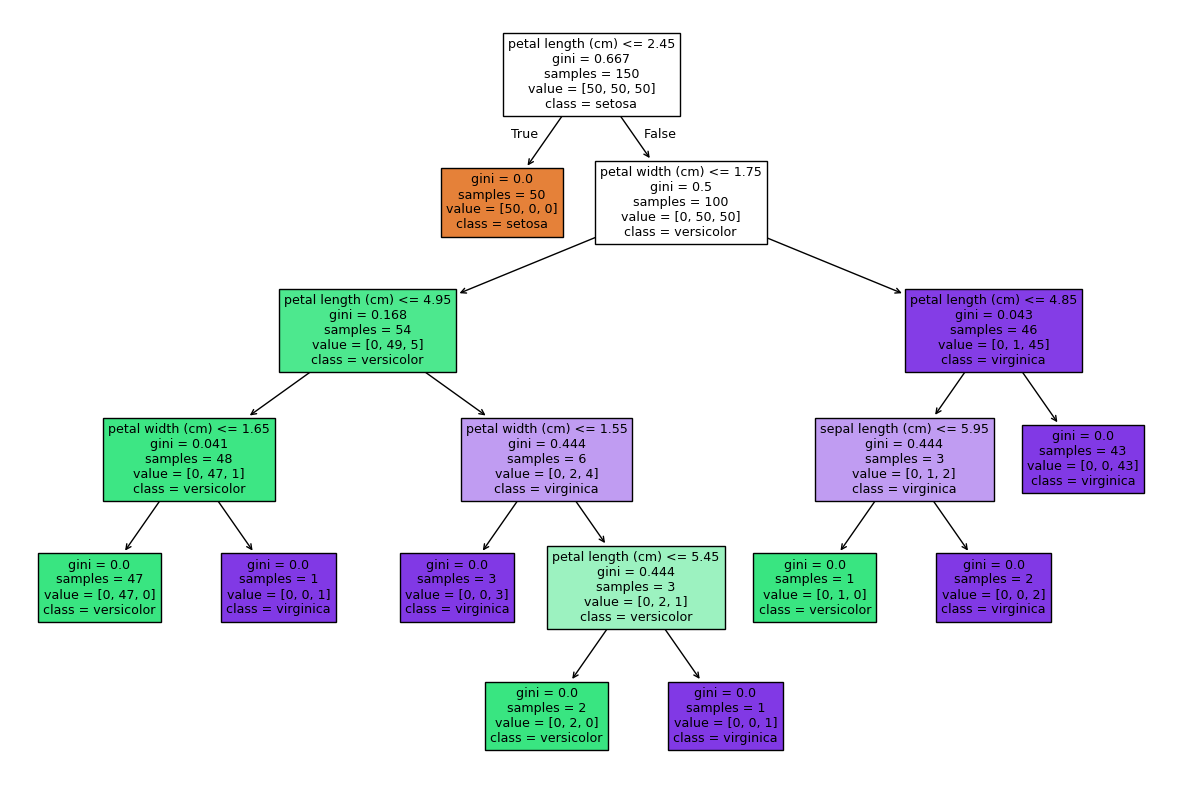

In [4]:
plt.figure(figsize=(15,10))


plot_tree(
    model,
    feature_names=feature_names,
    class_names= target_names,
    filled = True
)

plt.show()

In [5]:
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

print(importance.sort_values(by='Importance', ascending=False))

             Feature  Importance
2  petal length (cm)    0.564056
3   petal width (cm)    0.422611
0  sepal length (cm)    0.013333
1   sepal width (cm)    0.000000


In [6]:
root_feature_index = model.tree_.feature[0]

print("Root Node Feature:")
print(feature_names[root_feature_index])

Root Node Feature:
petal length (cm)


Max Depth পরিবর্তন করলে কী হয়?

In [8]:
model1 = DecisionTreeClassifier(max_depth=1)
model1.fit(X, y)

DecisionTreeClassifier(max_depth=1)

In [9]:
model3 = DecisionTreeClassifier()
model3.fit(X, y)

DecisionTreeClassifier()

In [10]:
model2 = DecisionTreeClassifier(max_depth=3)
model2.fit(X, y)

DecisionTreeClassifier(max_depth=3)

Max Depth : 1
Accuracy : 0.6666666666666666
Root Node : petal length (cm)

Feature Importance:
sepal length (cm) : 0.0
sepal width (cm) : 0.0
petal length (cm) : 1.0
petal width (cm) : 0.0


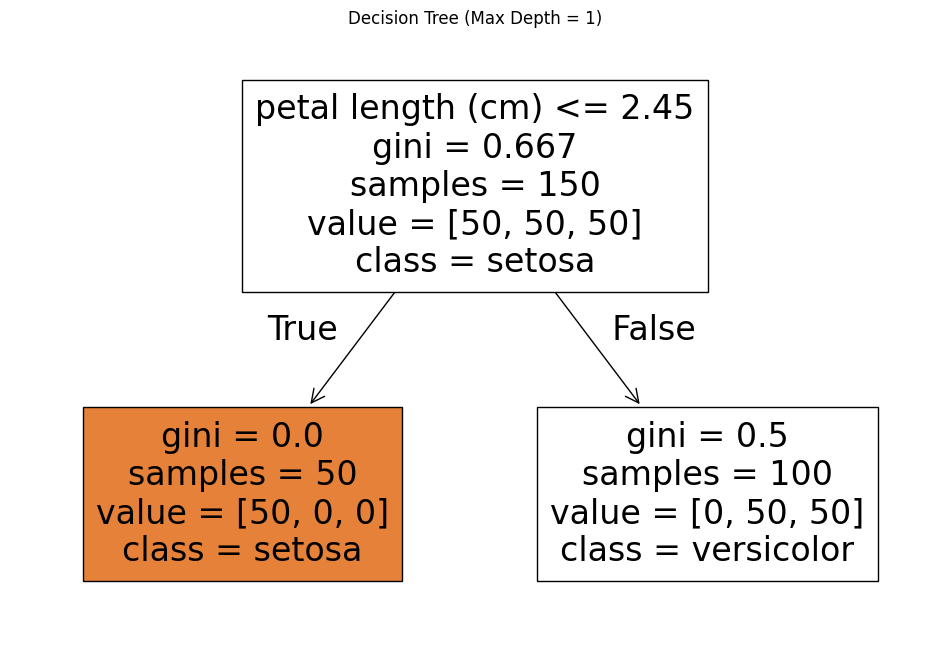

Max Depth : 2
Accuracy : 0.96
Root Node : petal length (cm)

Feature Importance:
sepal length (cm) : 0.0
sepal width (cm) : 0.0
petal length (cm) : 0.562
petal width (cm) : 0.438


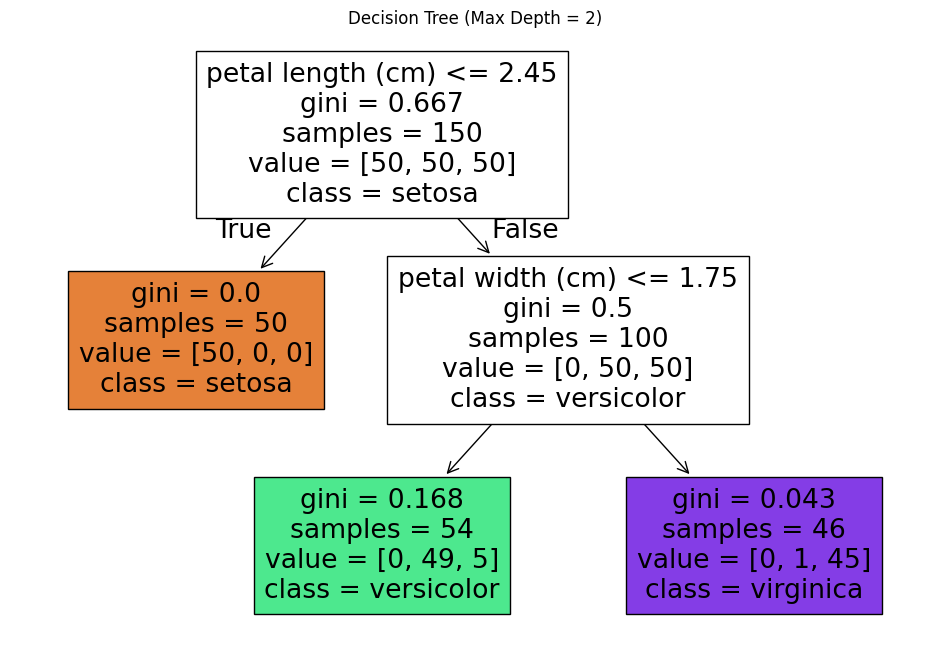

Max Depth : 3
Accuracy : 0.9733333333333334
Root Node : petal length (cm)

Feature Importance:
sepal length (cm) : 0.0
sepal width (cm) : 0.0
petal length (cm) : 0.586
petal width (cm) : 0.414


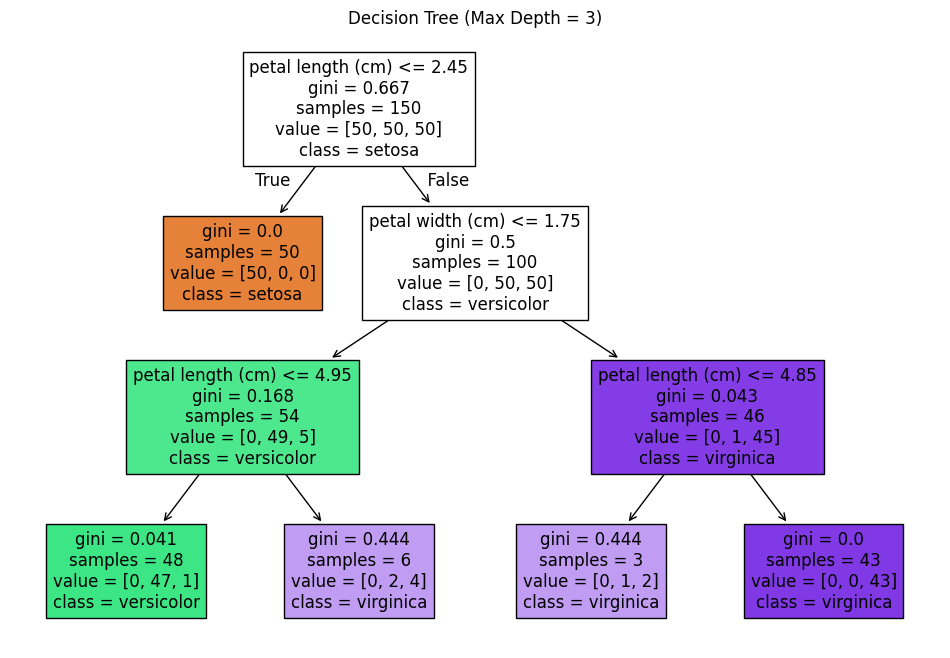

Max Depth : 4
Accuracy : 0.9933333333333333
Root Node : petal length (cm)

Feature Importance:
sepal length (cm) : 0.0
sepal width (cm) : 0.014
petal length (cm) : 0.558
petal width (cm) : 0.428


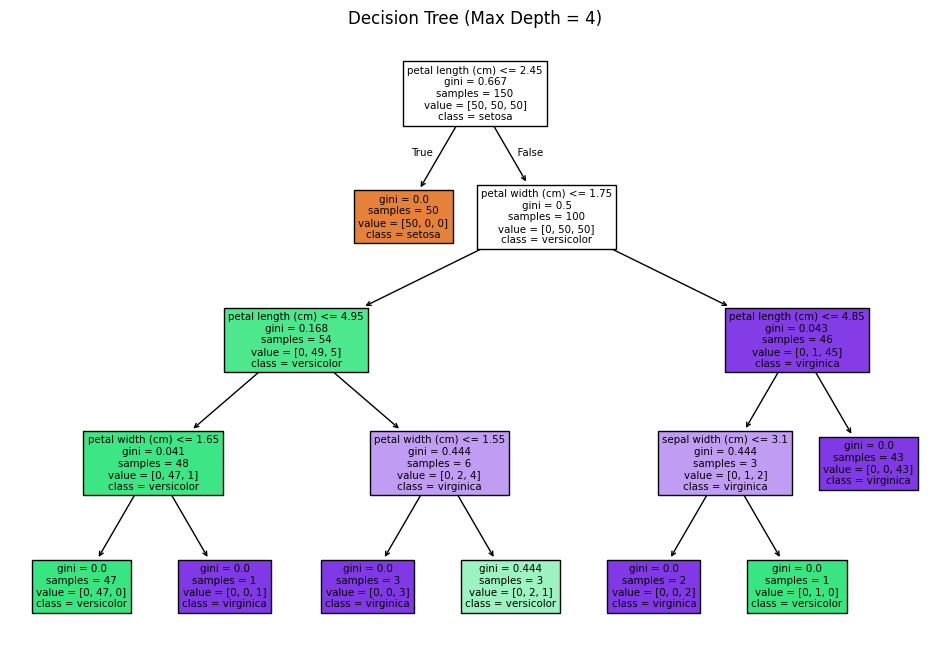

Max Depth : None
Accuracy : 1.0
Root Node : petal length (cm)

Feature Importance:
sepal length (cm) : 0.013
sepal width (cm) : 0.0
petal length (cm) : 0.564
petal width (cm) : 0.423


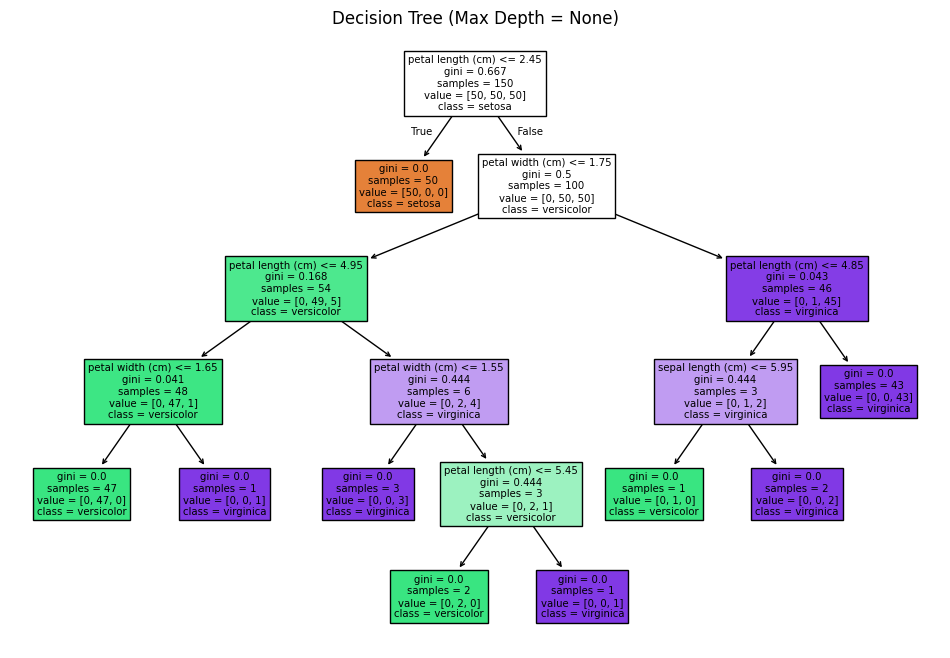

In [11]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load Dataset
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

# Different Max Depth Values
depths = [1, 2, 3, 4, None]

for depth in depths:

    # Create Model
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Train Model
    model.fit(X, y)

    # Accuracy
    accuracy = model.score(X, y)

    print("=" * 40)
    print("Max Depth :", depth)
    print("Accuracy :", accuracy)

    # Root Node
    root_index = model.tree_.feature[0]
    print("Root Node :", feature_names[root_index])

    # Feature Importance
    print("\nFeature Importance:")
    for feature, importance in zip(feature_names, model.feature_importances_):
        print(feature, ":", round(importance, 3))

    # Visualization
    plt.figure(figsize=(12, 8))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=target_names,
        filled=True
    )
    plt.title(f"Decision Tree (Max Depth = {depth})")
    plt.show()